In [7]:
import numpy as np
from pylab import *
from craco.cardcap import CardcapFile
from astropy.io import fits
from craft.craftcor import MiriadGainSolutions
import glob
from craco.search_pipeline import location2pix, get_grid_lut_from_plan, grid_candidates,wait_for_starts,waitall,print_candidates
from craco.search_pipeline import NBINARY_POINT_FDMTIN 
import craco
import craco.search_pipeline
from craco.pyxrtutil import *
import craft.craco_plan

from craft import uvfits

from craft.craco_plan import PipelinePlan
from craft.craco import printstats,bl2ant
import logging
import time
import scipy

%matplotlib notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
cd /data/craco/ban115/craco-python/notebooks/data/SB43128/run3

/data/craco/ban115/craco-python/notebooks/data/SB43128/run3


In [9]:
fits='SB43128_run3.uvfits'
#its='/data/craco/ban115/test_data/frb_d0_t0_a1_sninf_lm00/frb_d0_t0_a1_sninf_lm00.fits'

xclbin='/data/craco/ban115/builds/binary_container_fe3fef0d.xclbin'
alloc_device_only=True

In [10]:
f = uvfits.open(fits)
plan = PipelinePlan(f, "--ndm 511 --flag-ants 23 --target-input-rms 16")

parsing values --ndm 511 --flag-ants 23 --target-input-rms 16


/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=259.0 1-3 uvpix=(0, 254)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=260.0 1-4 uvpix=(2, 0)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=522.0 2-10 uvpix=(15, 0)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=522.0 2-10 uvpix=(16, 0)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=

Upper registers [(2, 1), (3, 1), (14, 1), (15, 1), (166, 1), (167, 1), (168, 1), (169, 1), (170, 1), (236, 1), (237, 1), (241, 1), (243, 1), (248, 1), (249, 1), (255, 1), (33, 2), (34, 2), (35, 2), (46, 2), (51, 2), (52, 2), (53, 2), (54, 2), (206, 2), (207, 2), (208, 2), (209, 2), (224, 2), (225, 2), (226, 2), (235, 2)]
Lower registers [(1, 2), (2, 3), (2, 4), (1, 5), (4, 5), (4, 7), (5, 8), (6, 8), (5, 9), (7, 9), (8, 9), (4, 10), (6, 10), (8, 10), (1, 11), (5, 11), (6, 11), (8, 11), (9, 11), (1, 12), (5, 12), (7, 12), (7, 13), (12, 14), (13, 14), (12, 15), (13, 15), (7, 16), (14, 16), (15, 16), (7, 17), (15, 17)]


In [11]:
values = craco.search_pipeline.get_parser().parse_args([])
plan.values.subtract = False

In [54]:
from craco import calibration
g = calibration.load_gains('run3.mir')
#g = np.ma.masked_where(g,np.abs(g) >0 )
g.shape



Using MIRIAD bandpass solutions


(36, 288, 2)

In [55]:
# apply flags
#g.mask[:,70:130,:] = True
#g.mask[:,210:,:] = True
chanlist = [70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287]
g.mask[:,chanlist,:] = True
#g[:,chanlist,:].mask = True #this doesn't work
soln = calibration.gains2solarray(plan,g)

<IPython.core.display.Javascript object>


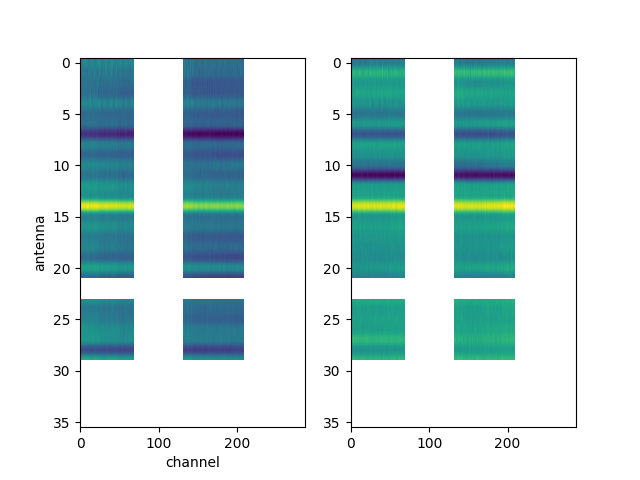

In [56]:
fig, ax = subplots(1,2)

ax[0].imshow(abs(g[...,0]), aspect='auto')
ax[0].set_xlabel('channel')
ax[0].set_ylabel('antenna')
ax[1].imshow(abs(g[...,1]), aspect='auto')

<IPython.core.display.Javascript object>


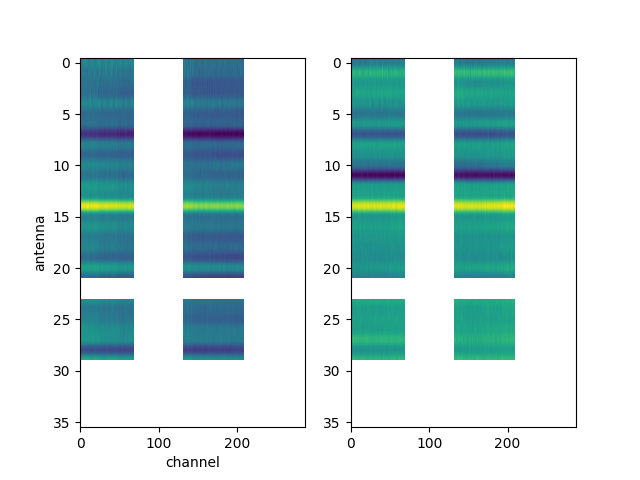

In [57]:
fig, ax = subplots(1,2)

ax[0].imshow(abs(g[...,0]), aspect='auto')
ax[0].set_xlabel('channel')
ax[0].set_ylabel('antenna')
ax[1].imshow(abs(g[...,1]), aspect='auto')

In [58]:
g.shape

(36, 288, 2)

<IPython.core.display.Javascript object>


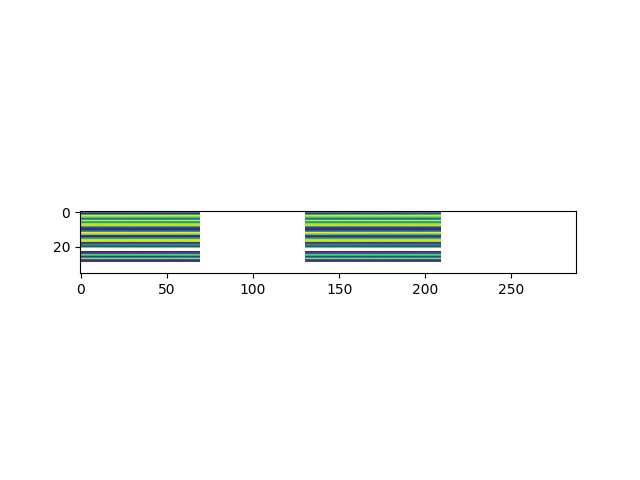

In [18]:
figure()
imshow(g[:,:,0].real)

In [10]:
device = pyxrt.device(0)
xbin = pyxrt.xclbin(xclbin)
uuid = device.load_xclbin(xbin)
p = craco.search_pipeline.Pipeline(device, xbin, plan, alloc_device_only)

Kernel krnl_ddgrid_reader_4cu:krnl_ddgrid_reader_4cu_1 has groups
GID=0=32
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=15
Kernel krnl_grid_4cu:krnl_grid_4cu_1 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=6
Kernel krnl_grid_4cu:krnl_grid_4cu_2 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=7
Kernel krnl_grid_4cu:krnl_grid_4cu_3 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=20
Kernel krnl_grid_4cu:krnl_grid_4cu_4 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=-1
GID=4=-1
GID=5=21
Kernel fft2d:fft2d_1 has groups
Kernel fft2d:fft2d_2 has groups
Kernel fft2d:fft2d_3 has groups
Kernel fft2d:fft2d_4 has groups
Kernel krnl_boxc_4cu:krnl_boxc_4cu_1 has groups
GID=0=-1
GID=1=-1
GID=2=-1
GID=3=54
GID=4=54
GID=5=4
Kernel fdmt_tunable_c32:fdmt_tunable_c32_1 has groups
GID=0=52
GID=1=32
GID=2=53
GID=3=53
GID=4=14
Allocated 360428 bytes flags=flags.normal groupid=6 address=0x60000000
Allocated 360428 bytes flags=flags.normal groupid=7 address=0x70000000
Allo

In [11]:
vis_source = craco.search_pipeline.VisSource(plan, f, values)

In [12]:
for ibl, input_flat in enumerate(vis_source):
    print(input_flat.shape)
    break

(406, 288, 2, 256)


In [ ]:
g = p.gains.copy()
g

<IPython.core.display.Javascript object>


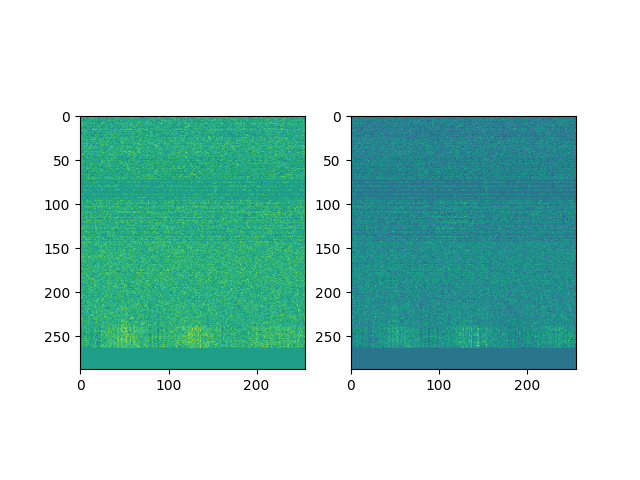

In [26]:
fig, ax = subplots(1,2)
input_flat_cal = p.calibrate_input(input_flat)
ax[0].imshow(input_flat.real[0,:,0,:])
ax[1].imshow(input_flat_cal.real[0,:,:])

In [25]:
# apply flags
#g.mask[:,70:130,:] = True
#g.mask[:,210:,:] = True
#soln = calibration.gains2solarray(plan,g)
#p.set_channel_flags(slice(70,130), True)
#p.set_channel_flags(slice(210, None), True)
#p.set_channel_flags(slice(None), False)
p.set_channel_flags(chanlist, True)

<IPython.core.display.Javascript object>


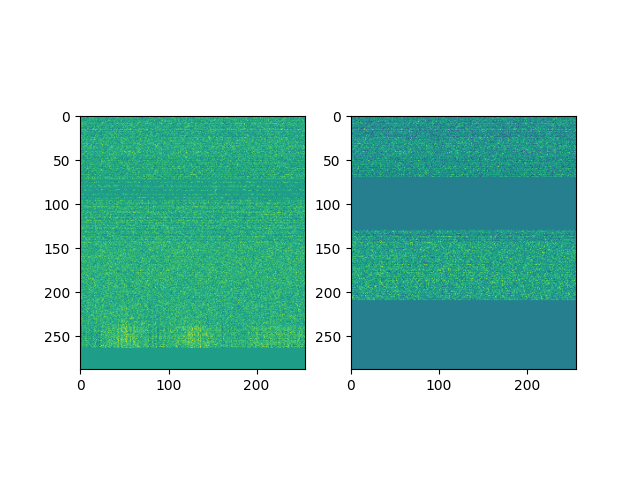

In [16]:
fig, ax = subplots(1,2)
input_flat_cal = p.calibrate_input(input_flat)
ax[0].imshow(input_flat.real[0,:,0,:])
ax[1].imshow(input_flat_cal.data.real[0,:,:])

In [ ]:
figure()
imshow(p.gains[:,:,0].real)
xlabel('Channel')
ylabel('Antenna')

In [ ]:
input_flat_cal.shape

In [ ]:
input_

In [ ]:
plan.values.subtract = True
p.plan.values.target_input_rms=32
p.set_calibration_gains(g)
input_flat_cal = p.calibrate_input(input_flat.copy())

def interp_model(input_flat, navg=6):    
    # average over time
    print(input_flat.shape)
    model = input_flat.mean(axis=-1)
    print(model.shape)
    # squish pols in to 
    chan_avg_model = model.reshape(model.shape[0], -1, navg).mean(axis=-1)
    chans = np.arange(chan_avg_model.shape[1])
    print(chan_avg_model.shape)
    print(chans)
    interp = scipy.interpolate.interp1d(chans, chan_avg_model, kind='linear', axis=-1, bounds_error=False, fill_value='extrapolate')
    upchans = np.arange(model.shape[1])/navg - 0.5
    print(upchans)
    interp_out = interp(upchans)
    
    return interp_out
    

def my_calibrate_input(input_flat):
    input_flat *= p.solarray
    # subtract model
    model = input_flat.mean(axis=-1)
    model = interp_model(model)        
    
    input_flat -= model
    
    # sum pols
    input_flat = input_flat.mean(axis=2)        
    
    return input_flat

#input_flat_cal = my_calibrate_input(input_flat.copy())


In [ ]:
p.solarray.shape
figure()
imshow(p.solarray[:,:,0,0].real)

In [ ]:
input_flat_cal.shape
figure()
imshow(input_flat_cal.mean(axis=-1).real)

In [ ]:
input_flat_cal.shape

In [ ]:
fig,ax = subplots(1,3,sharex=True)
fig.set_size_inches((10,5))
phasecenter = input_flat_cal.mean(axis=0)
phasecenter_t = phasecenter.mean(axis=0)
ax[0].imshow(phasecenter.real)
ax[1].imshow(phasecenter.imag)
ax[2].plot(phasecenter_t.real/phasecenter_t.real.std(), label='real')
ax[2].plot(phasecenter_t.imag/phasecenter_t.imag.std(), label='imat')
ax[0].set_title('real')
ax[1].set_title('Imag')
ax[2].set_title('time series')
ax[0].set_xlabel('sample')
ax[1].set_xlabel('sample')
ax[2].set_xlabel('sample')
ax[0].set_ylabel('channel')
ax[2].legend()


In [ ]:
input_flat_bp = input_flat * soln
input_flat_bp.shape

In [ ]:
soln.shape

In [ ]:
figure()
#imshow(soln.mask[0,:,0,0])
imshow(input_flat_bp[:,:,0,0].real)

In [ ]:
input_flat_bp.mask.shape
figure()
imshow(soln.mask[:,:,0,0].astype(int))

In [ ]:
figure()

mdl = interp_model(input_flat_bp.real)
flatavg = input_flat_bp.mean(axis=-1)
                   
plot(np.real(flatavg[:10,:,0]).T);
plot(mdl[:10,:].T);

In [ ]:
input_flat_cal.shape

In [ ]:
input_flat_cal.mean()

In [ ]:
input_flat_cal.real.std()

In [ ]:
figure()
meantime = input_flat_cal.mean(axis=0).mean(axis=0)
plot(meantime.real/meantime.real.std(), label='real')
plot(meantime.imag/meantime.real.std(), label='imag')
xlabel('Time')
legend()
ylabel('Coherent sum S/N')

In [ ]:
input_flat_cal.real.mean()

In [ ]:
input_flat_cal.real.std()

In [ ]:
figure()
plot(input_flat_cal.real.std(axis=0));
xlabel('channel')
title('Std over time')

In [ ]:
figure()
plot(input_flat_cal.real.std(axis=0).mean(axis=1));
xlabel('channel')
title('Std over time and baseline')

In [ ]:
rfimask = input_flat_cal.real.std(axis=0)
figure()
imshow(rfimask, origin='lower')
xlabel('time')
ylabel('channel')

In [ ]:
rfimask = input_flat_cal.real.std(axis=2)
figure()
imshow(rfimask, origin='lower')
xlabel('channel')
ylabel('baseline')
title('STD over time')

In [ ]:
#input_flat[220:,:,:] = 0
#input_flat[73:96,:,:] = 0

In [ ]:
np.std(input_flat_cal.imag)

In [ ]:
nosieamp = []
nsum = p.plan.nbl*p.plan.nf
values.input_scale = 1
values.threshold = 1
#p.solarray.mask[:,70:95,:] = True
#p.solarray.mask[:,238:,:] = True
p.copy_input(input_flat.copy(), values)
p.run(0,values).wait()
c = p.get_candidates()
len(c)

In [ ]:
p.last_bc_noise_level

In [ ]:
expected_image_noise_level = p.last_bc_noise_level*4 # bc scales image by 4x for some reason
expected_image_noise_level

In [ ]:
last_threshold = p.last_bc_noise_level*values.threshold
last_threshold

In [ ]:
c.dtype

In [ ]:
fig,ax = subplots(2,2,sharex=True)
mask = (c['dm'] == 0) & (c['loc_2dfft'] == 0)
c = c[mask]
sn = c['snr'] #[c['dm'] == 0]
ax[0,0].plot(sn)
ax[0,0].set_ylabel('S/N')

print(sn.mean(), sn.std())
ax[0,1].plot(c['dm'])
ax[0,1].set_ylabel('DM')
ax[1,0].plot(c['boxc_width'])
ax[1,0].set_ylabel('BOXC')
ax[1,1].plot(c['time'])
ax[1,1].set_ylabel('TIME')

In [ ]:
mask = (c['dm'] == 0) & (c['loc_2dfft'] == 0)
c[mask]

In [ ]:
inbuf = p.inbuf.copy_from_device().nparr
inbuf.shape

In [ ]:
inbuf[...,0].mean()

In [ ]:
(inbuf != 0).sum()/256/2


In [ ]:
inbuf[...,0].std()

In [ ]:
bc = p.boxcar_history.copy_from_device().nparr
bc.shape

In [ ]:
figure()
plot(bc[:,0,0,0])
xlabel('iDM')
ylabel('Center pixel value')

In [ ]:
bc0 = np.fft.fftshift(bc[0,...])
fig,ax = subplots(1,2)
ax[1].imshow(bc0.std(axis=0))
ax[1].set_title('STD over BC')
ax[0].imshow(bc0.mean(axis=0))
ax[0].set_title(f'Mean over BC std={bc0.mean(axis=0).std():0.1f}')


In [ ]:
figure()
hist(bc0.flat, bins=50)
print(bc0.std())

In [ ]:
fig = figure()
img = bc0[4,:,:]
imshow(img)
printstats(img)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
fig = figure()
img = np.fft.fftshift(bc0-bc0.mean(axis=0, keepdims=True))
ax = imshow(img[0,:,:])
def animate(frame_num):
    nbc = img.shape[0]
    ax.set_data(img[frame_num % nbc])
    
    return ax

anim = FuncAnimation(fig, animate, frames=10, interval=50, repeat=False)
anim.save('bc_animation.gif', writer='pillow', fps=15)
#plt.show()

In [ ]:
input_flat_cal.mask[:,70:95,:] = True
input_flat_cal.mask[:,238:,:] = True


In [ ]:
input_flat_cal.shape

In [ ]:
sn = input_flat_cal.real.mean(axis=2).real/input_flat_cal.real.std(axis=2)

In [ ]:
figure()
plot(sn.T);
ylabel('S/N per baseline')
xlabel('Channel')

In [ ]:
figure()
snbl = sn.mean(axis=1)/sn.std(axis=1)
plot(snbl)
xlabel('baseline')
ylabel('S/N')

In [ ]:
input_flat_cal.shape

In [ ]:
figure()
plot(input_flat_cal.mean(axis=0).mean(axis=0).real)

In [ ]:
c = p.get_candidates()
len(c)

In [ ]:
c[0]

# Look at numpy history files

In [ ]:
!ls -lh *.npy

In [ ]:
inbuf = np.load('uv_data_iblk0.npy')
inbuf.shape

In [ ]:
inbufrs = np.transpose(inbuf, [0,3,1,2,4]).reshape((-1,256,32,2))
inbufrs.shape

In [ ]:
fig, ax = subplots(1,2)
ax[0].imshow(inbufrs[:,:,:,0].mean(axis=1), aspect='auto')
ax[1].imshow(inbufrs[:,:,:,1].mean(axis=1), aspect='auto')

In [ ]:
inbuf.shape

In [ ]:
figure()
plot(inbuf[0,:,:,0,:].mean(axis=0))

In [ ]:
figure()
plot(inbuf[0,:,:,0,:].std(axis=0))

In [ ]:
!ls -lh *.npy

In [ ]:
!pwd


In [ ]:
bc = np.load('boxcar_hist_iblk0.npy')
bc.shape

In [ ]:
figure()
imshow(np.fft.fftshift(bc[0,:,:,:]).mean(axis=0))

# with search pipeline dump dadta

In [61]:
!ls -lrth *.npy

-rw-rw-r-- 1 ban115 ban115 2.2M Sep 28 18:21 test.npy
-rw-rw-r-- 1 ban115 ban115 590M Sep 29 11:27 input_iblk3.npy
-rw-rw-r-- 1 ban115 ban115 145M Sep 29 11:27 uv_data_iblk3.npy
-rw-rw-r-- 1 ban115 ban115 897M Sep 29 11:27 boxcar_hist_iblk3.npy
-rw-rw-r-- 1 ban115 ban115 590M Sep 29 11:28 input_iblk4.npy
-rw-rw-r-- 1 ban115 ban115 145M Sep 29 11:28 uv_data_iblk4.npy
-rw-rw-r-- 1 ban115 ban115 897M Sep 29 11:28 boxcar_hist_iblk4.npy
-rw-rw-r-- 1 ban115 ban115 590M Sep 29 11:28 input_iblk5.npy
-rw-rw-r-- 1 ban115 ban115 145M Sep 29 11:28 uv_data_iblk5.npy
-rw-rw-r-- 1 ban115 ban115 897M Sep 29 11:29 boxcar_hist_iblk5.npy
-rw-rw-r-- 1 ban115 ban115 590M Sep 29 11:29 input_iblk6.npy
-rw-rw-r-- 1 ban115 ban115 145M Sep 29 11:29 uv_data_iblk6.npy
-rw-rw-r-- 1 ban115 ban115 897M Sep 29 11:29 boxcar_hist_iblk6.npy
-rw-rw-r-- 1 ban115 ban115 590M Sep 29 11:29 input_iblk7.npy
-rw-rw-r-- 1 ban115 ban115 145M Sep 29 11:29 uv_data_iblk7.npy
-rw-rw-r-- 1 ban115 ban115 897M Sep 29 11:30 boxcar_hist_i

In [62]:
uvin = np.load('uv_data_iblk0.npy')
uvin.shape


(579, 256, 32, 8, 2)

In [63]:
np.all(uvin==0)

False

In [64]:
np.all(uvin[...,1] == 0)

False

In [65]:
uvin[uvin != 0].std()

128.1673869839324

<IPython.core.display.Javascript object>


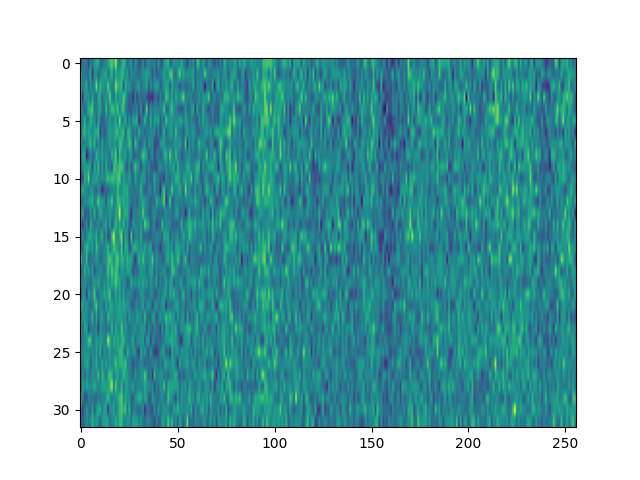

In [66]:
figure()
imshow(uvin[...,0].mean(axis=(0,3)).T, aspect='auto')

In [67]:
uvin.shape

(579, 256, 32, 8, 2)

<IPython.core.display.Javascript object>


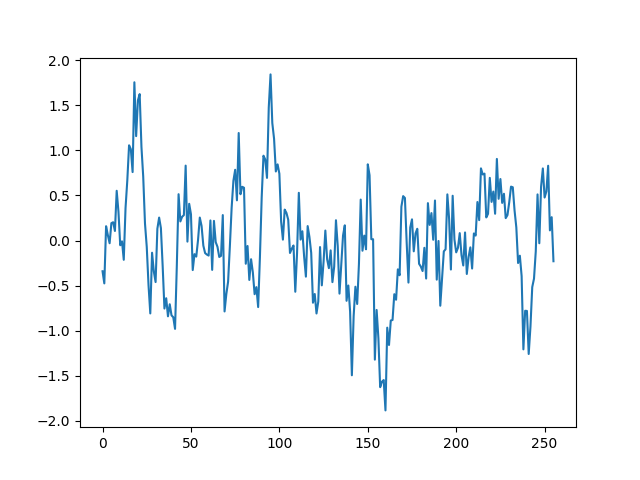

In [68]:
figure()
plot(uvin[...,0].mean(axis=(0,2,3)).T)

In [69]:
bc = np.load('boxcar_hist_iblk0.npy')
bc.shape

(1024, 7, 256, 256)

<IPython.core.display.Javascript object>


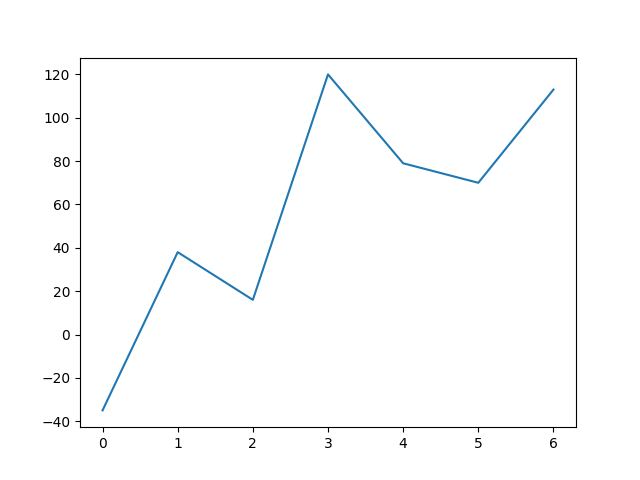

In [70]:
figure()
plot(bc[0,:,0,0])

In [71]:
bc[0].std()

31.32014671735449

<IPython.core.display.Javascript object>


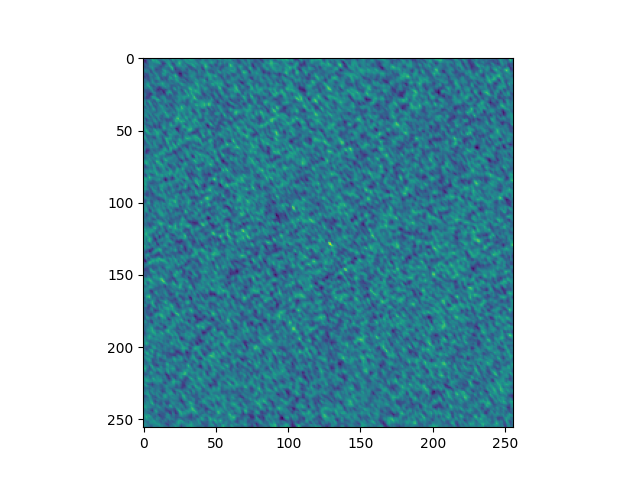

In [72]:
figure()
imshow(np.fft.fftshift(bc[0,3,...]))

In [73]:
print(printstats(bc[0,...]))

 max/min/mean/rms/sum/S/N = 1.83e+02/-1.47e+02/-5.00e-01/3.13e+01/-2.29e+05/5.8 peak at (3, 1, 1)


<IPython.core.display.Javascript object>


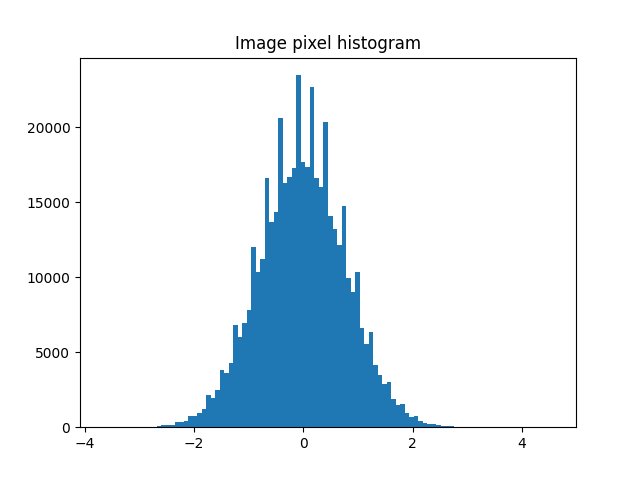

(array([2.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00,
        5.0000e+00, 1.2000e+01, 7.0000e+00, 2.1000e+01, 2.7000e+01,
        3.5000e+01, 4.4000e+01, 7.1000e+01, 1.3200e+02, 1.3000e+02,
        1.6800e+02, 3.3500e+02, 3.1500e+02, 4.0100e+02, 7.6400e+02,
        7.6700e+02, 9.5000e+02, 1.2240e+03, 2.1200e+03, 1.9260e+03,
        2.4700e+03, 3.8250e+03, 3.6280e+03, 4.2880e+03, 6.8290e+03,
        5.9880e+03, 6.9560e+03, 7.8040e+03, 1.2015e+04, 1.0311e+04,
        1.1229e+04, 1.6587e+04, 1.3653e+04, 1.4359e+04, 2.0623e+04,
        1.6306e+04, 1.6706e+04, 1.7275e+04, 2.3461e+04, 1.7647e+04,
        1.7314e+04, 2.2695e+04, 1.6640e+04, 1.5994e+04, 2.0329e+04,
        1.4055e+04, 1.3191e+04, 1.2147e+04, 1.4733e+04, 9.9140e+03,
        8.9870e+03, 1.0368e+04, 6.6420e+03, 5.5720e+03, 6.3680e+03,
        4.1630e+03, 3.4880e+03, 2.8750e+03, 3.0440e+03, 1.8590e+03,
        1.4620e+03, 1.5140e+03, 9.1900e+02, 7.0100e+02, 7.2500e+02,
        4.1600e+02, 3.0100e+02, 2.3600e+02, 2.25

In [74]:
figure()
title('Image pixel histogram')
hist(bc[0,...].flatten()/40, bins=100)
#ylim(0,10)

In [75]:
cd /data/craco/ban115/craco-python/notebooks/data/SB43128/run3

/data/craco/ban115/craco-python/notebooks/data/SB43128/run3


In [76]:
ls *.npy

boxcar_hist_iblk0.npy  input_iblk1.npy    uv_data_iblk1.npy
boxcar_hist_iblk1.npy  input_iblk2.npy    uv_data_iblk2.npy
boxcar_hist_iblk2.npy  input_iblk3.npy    uv_data_iblk3.npy
boxcar_hist_iblk3.npy  input_iblk4.npy    uv_data_iblk4.npy
boxcar_hist_iblk4.npy  input_iblk5.npy    uv_data_iblk5.npy
boxcar_hist_iblk5.npy  input_iblk6.npy    uv_data_iblk6.npy
boxcar_hist_iblk6.npy  input_iblk7.npy    uv_data_iblk7.npy
boxcar_hist_iblk7.npy  input_iblk8.npy    uv_data_iblk8.npy
boxcar_hist_iblk8.npy  input_iblk9.npy    uv_data_iblk9.npy
boxcar_hist_iblk9.npy  test.npy
input_iblk0.npy        uv_data_iblk0.npy


In [78]:
from craco.plot_cand import load_cands

In [259]:
c = load_cands('candidates_withsub.txt')

In [260]:
len(c)

10099

In [261]:
c.dtype

dtype([('SNR', '<f4'), ('lpix', '<u2'), ('mpix', '<u2'), ('boxc_width', 'u1'), ('time', '<i8'), ('dm', '<i8'), ('iblk', '<i8'), ('rawsn', '<i8'), ('total_sample', '<i8'), ('obstime_sec', '<f4'), ('mjd', '<f8'), ('dm_pccm3', '<f4'), ('ra_deg', '<f8'), ('dec_deg', '<f8')])

In [262]:
c0 = c[(c['iblk'] >= 0) & (c['time'] > 255-8) & (c['boxc_width'] == 0)]

In [263]:
c0

array([],
      dtype=[('SNR', '<f4'), ('lpix', '<u2'), ('mpix', '<u2'), ('boxc_width', 'u1'), ('time', '<i8'), ('dm', '<i8'), ('iblk', '<i8'), ('rawsn', '<i8'), ('total_sample', '<i8'), ('obstime_sec', '<f4'), ('mjd', '<f8'), ('dm_pccm3', '<f4'), ('ra_deg', '<f8'), ('dec_deg', '<f8')])

In [264]:
mycand = c0[0]
mycand

IndexError: index 0 is out of bounds for axis 0 with size 0

In [265]:
iblk = mycand['iblk']
iblk
iblk = 0

In [266]:
bc = np.load(f'boxcar_hist_iblk{iblk}.npy')
bc.shape

(1024, 7, 256, 256)

In [267]:
myimg = np.fft.fftshift(bc[0,1,:,:])

In [268]:
myimg[mycand['lpix'],mycand['mpix']]/4 # this agrees exactly with the candidatefile

-4.75

In [269]:
assert int(myimg[mycand['lpix'],mycand['mpix']]/4) == mycand['rawsn'] # this agrees exactly with the candidatefile

AssertionError: 

<IPython.core.display.Javascript object>


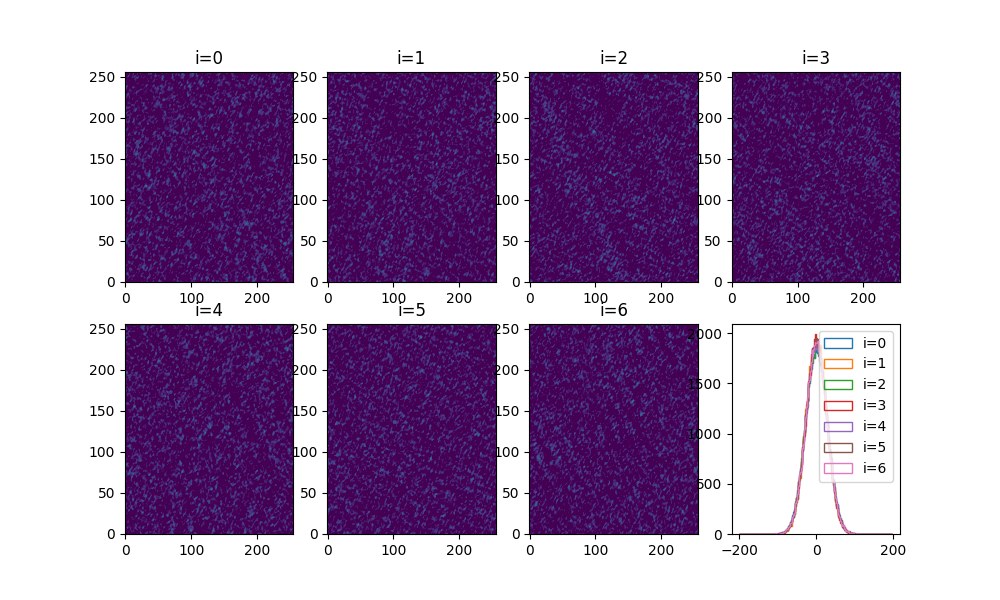

In [270]:
fig, ax = subplots(2,4)
fig.set_size_inches((10,6))
ax = ax.flatten()
for i in range(bc.shape[1]):
    ax[i].imshow(np.fft.fftshift(bc[0,i,...]),origin='lower',aspect='auto',vmin=0,vmax=40*6)
    ax[i].set_title(f'i={i}')
    ax[-1].hist(bc[0,i,...].flatten(), histtype='step', bins=np.arange(-200,200,2), label=f'i={i}')
    
ax[-1].legend()




<IPython.core.display.Javascript object>


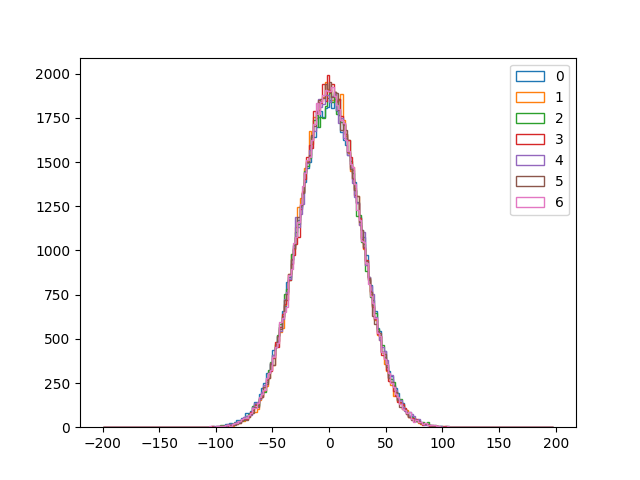

In [271]:
figure()
stdvbc = []
meanvbc = []
for i in range(bc.shape[1]):
    hist(bc[0,i,...].flatten(), histtype='step', bins=np.arange(-200,200,2), label=str(i))
    
legend()


<IPython.core.display.Javascript object>


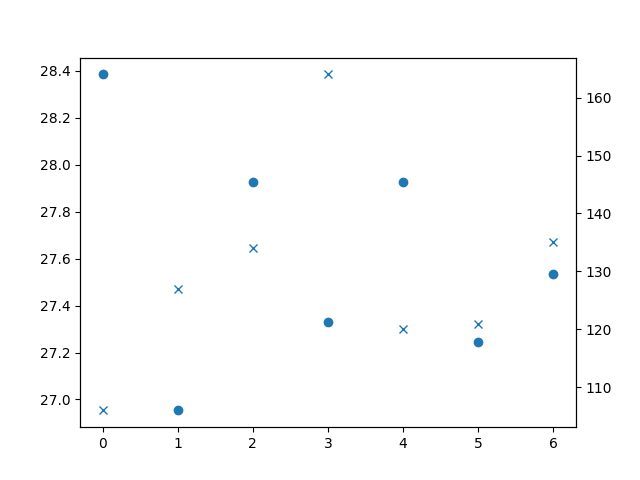

In [272]:
figure()

plot(bc[0,...].std(axis=(1,2)), 'o')
twinx()
plot(bc[0,...].max(axis=(1,2)), 'x')

<IPython.core.display.Javascript object>


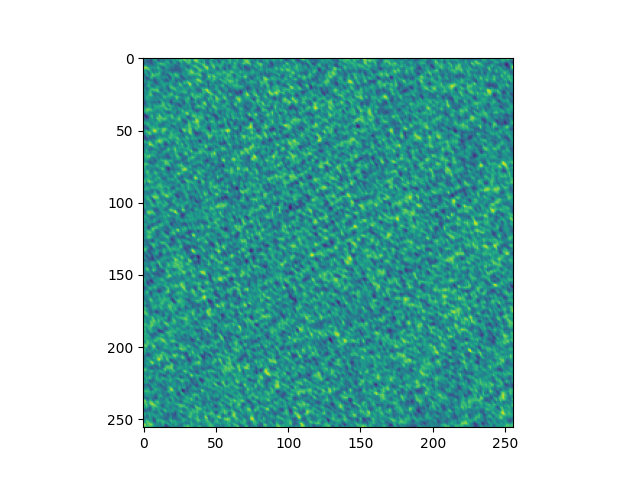

In [214]:
figure()
imshow(bc[0,1,:,:] - bc[0,2,:,:])

In [215]:
blin = np.load(f'input_iblk{iblk}.npy', allow_pickle=True)
blin.shape

(406, 288, 256)

<IPython.core.display.Javascript object>


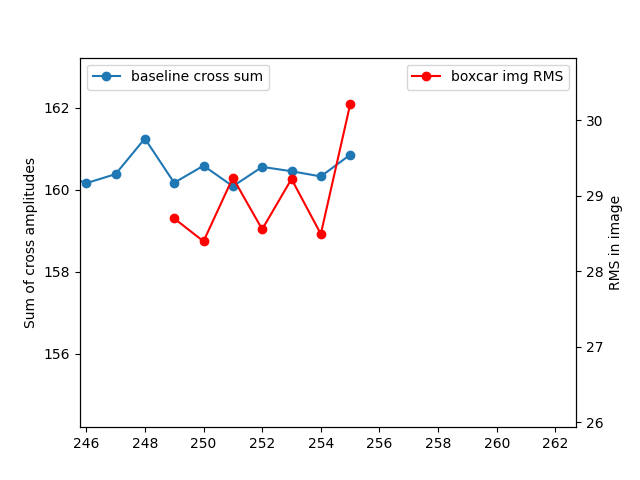

/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/numpy/ma/core.py:468: ComplexWarning: Casting complex values to real discards the imaginary part
  fill_value = np.array(fill_value, copy=False, dtype=ndtype)


In [258]:
figure()
#plot(np.abs(uvinc).sum(axis=(0,2)), 'o-', label='cross sum')
plot(np.abs(blin).mean(axis=(0,1)), 'o-', label='baseline cross sum')
ylabel('Sum of cross amplitudes')
legend(loc='upper left')
twinx()
plot(255-np.arange(7), bc[0,...].std(axis=(1,2)),'ro-', label='boxcar img RMS')
ylabel('RMS in image')
xlabel('Sample')
legend(loc='upper right')

<IPython.core.display.Javascript object>


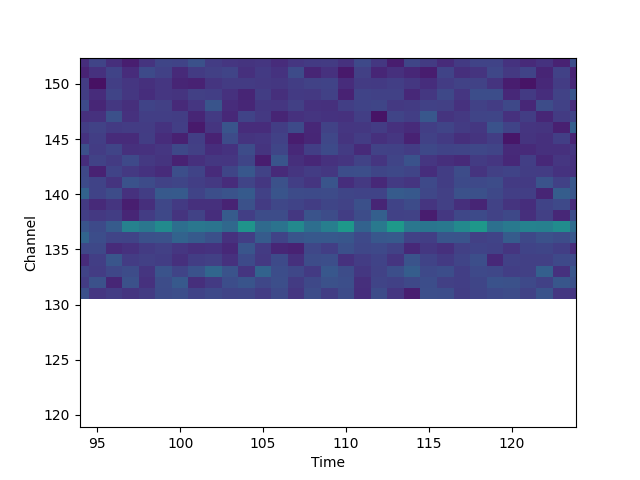

/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/numpy/ma/core.py:468: ComplexWarning: Casting complex values to real discards the imaginary part
  fill_value = np.array(fill_value, copy=False, dtype=ndtype)


160.34419190818303 5.001521321178303


In [217]:
figure()
absblin = np.abs(blin).mean(axis=0)
imshow((absblin - absblin.mean())/absblin.std(), aspect='auto', origin='lower')
xlabel('Time')
ylabel('Channel')
print(absblin.mean(), absblin.std())


In [173]:
data = np.ma.masked_array(np.arange(10), mask=np.zeros(10))
data

masked_array(data=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value=999999)

In [174]:
data = np.ma.masked_array(np.arange(10), mask=np.zeros(10))
data.mask[[1,2,3]] = True
data

masked_array(data=[0, --, --, --, 4, 5, 6, 7, 8, 9],
             mask=[False,  True,  True,  True, False, False, False, False,
                   False, False],
       fill_value=999999)

In [175]:
data = np.ma.masked_array(np.arange(10), mask=np.zeros(10))
data.mask[1:4] = True
data

masked_array(data=[0, --, --, --, 4, 5, 6, 7, 8, 9],
             mask=[False,  True,  True,  True, False, False, False, False,
                   False, False],
       fill_value=999999)

In [176]:
data = np.ma.masked_array(np.arange(10), mask=np.zeros(10))
data[1:4].mask = True
data

masked_array(data=[0, --, --, --, 4, 5, 6, 7, 8, 9],
             mask=[False,  True,  True,  True, False, False, False, False,
                   False, False],
       fill_value=999999)

In [177]:
data = np.ma.masked_array(np.arange(10), mask=np.zeros(10))
data[[1,2,3]].mask = True # Doesn't mask! Mask remains False everywhere!
data

masked_array(data=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value=999999)

In [178]:
import sys, numpy; print(numpy.__version__, sys.version)

1.19.5 3.6.9 (default, Dec  8 2021, 21:08:43) 
[GCC 8.4.0]


In [179]:
blin.shape

(406, 288, 256)

In [180]:
blint = np.zeros((406,288,256,2), dtype=np.int16)

In [181]:
%timeit blint.mean(axis=2)

611 ms ± 28.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [182]:
%timeit blint.mean(axis=1)

46.4 ms ± 574 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [183]:
%timeit blint.mean(axis=0)

52 ms ± 1.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [149]:
%timeit blint.mean(axis=-1)

606 ms ± 3.68 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [218]:
from scipy import special

In [257]:
special.erfc(6*sqrt(2)/2)/2*256*256*1*8*10*30

0.15517681897245686